In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
def crear_enjambre(n_particles, mins, maxs): 
  # Creamos un enjambre de particulas
  # mins y maxs deben ser arrays/listas con los límites para cada dimensión
  n_dimensions = len(mins)
  particulas = np.zeros((n_particles, n_dimensions))

  for i in range(n_particles):
      for j in range(n_dimensions):
          particulas[i, j] = np.random.uniform(mins[j], maxs[j])

  return particulas

In [3]:
def fitness_function_f2(x, y):  
  return ((x**2 + y**2)**0.25)*((np.sin(50*(x**2 + y**2)**0.1))**2  + 1)

In [10]:
def pso(fitness_func, mins, maxs, c1 = 0.1, c2 = 0.7, n_particles = 10, max_iter=1000): 
  inicio = time.time()
  n_dimensions = len(mins)
  x = crear_enjambre(n_particles, mins, maxs)
  v = np.zeros_like(x)
  
  best_local = x.copy() 
  best_local_val = np.zeros(n_particles)

  for i in range(n_particles): 
    best_local_val[i] = fitness_func(x[i, 0], x[i, 1]) # x[i, 0] es la coord. x, x[i, 1] es la coord. y

  best_global = best_local[np.argmin(best_local_val)]
  best_global_val = fitness_func(best_global[0], best_global[1])

  history = [best_global_val]

  iter = 0
  while iter < max_iter: 
    for k in range(n_particles): 
      for i in range(n_dimensions): 
        r1, r2 = np.random.rand(), np.random.rand()
        v[k][i] += c1*r1*(best_local[k][i] - x[k][i]) + c2*r2*(best_global[i] - x[k][i])

      x[k] += v[k]

      x[k] = np.clip(x[k], mins, maxs)  # Usar clip en lugar de loops

      

      # Evaluamos el nuevo fitness de la particula
      val = fitness_func(x[k][0], x[k][1])

      if val < best_local_val[k]: 
        best_local[k] = x[k].copy()
        best_local_val[k] = val

      if val < best_global_val: 
        best_global_val = val
        best_global = x[k].copy()
    
    history.append(val)
    iter += 1
    
  fin = time.time()
  print(f"Mejor valor encontrado: {best_global_val:.6f}")
  print(f"En posición: {best_global[0]:.6f}, {best_global[1]:.6f}")
  print(f"El algoritmo terminó en {round(fin - inicio, 4)} segundos")

In [11]:
_ = pso(fitness_function_f2, [-100, -100], [100, 100], n_particles=100)

Mejor valor encontrado: 0.853095
En posición: 0.407019, 0.288575
El algoritmo terminó en 0.5963 segundos


## Graficamos

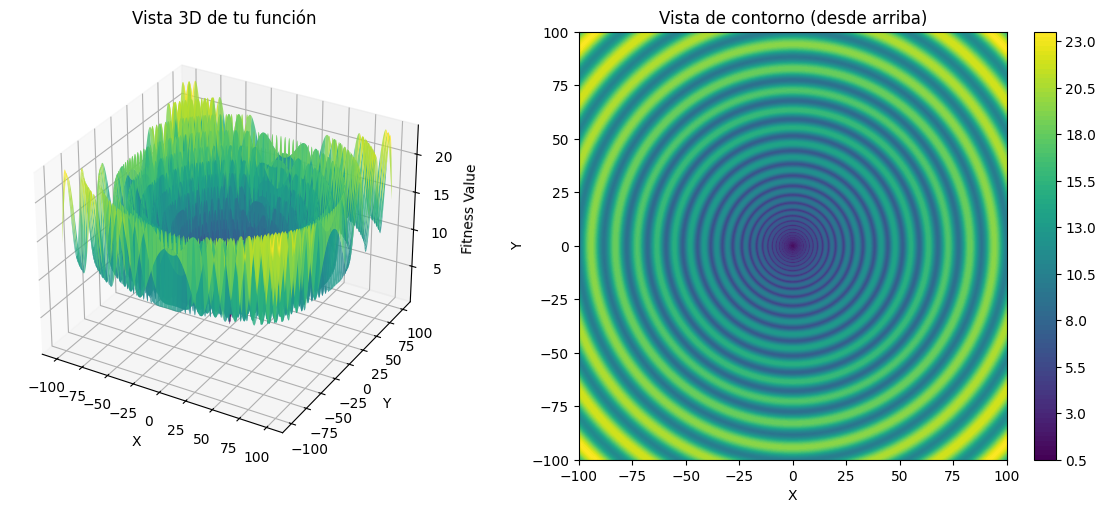

Mínimo encontrado en la malla:
Posición: (0.100100, 0.100100)
Valor mínimo: 0.546785


In [7]:
# Paso 1: Crear los rangos x e y
x = np.linspace(-100, 100, 1000)  # 100 puntos entre -2 y 2
y = np.linspace(-100, 100, 1000)  # 100 puntos entre -2 y 2
    
# Paso 2: Crear la malla
X, Y = np.meshgrid(x, y)
    
# Paso 3: Evaluar tu función en cada punto
Z = fitness_function_f2(X, Y)
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
surface = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Fitness Value")
ax1.set_title('Vista 3D de tu función')

ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=100, cmap='viridis')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Vista de contorno (desde arriba)')
ax2.set_aspect('equal')  # Esto hace que los ejes tengan la misma escala

plt.colorbar(contour, ax=ax2)
    
plt.tight_layout()
plt.show()

min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_x = X[min_idx]
min_y = Y[min_idx]
min_value = Z[min_idx]

print(f"Mínimo encontrado en la malla:")
print(f"Posición: ({min_x:.6f}, {min_y:.6f})")
print(f"Valor mínimo: {min_value:.6f}")

In [10]:
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.patches as patches

def pso_animated(fitness_func, mins, maxs, c1=2.0, c2=2.0, w=0.9, n_particles=30, max_iter=100, save_gif=True):
    """
    PSO con animación que guarda las posiciones de cada iteración
    """
    inicio = time.time()
    n_dimensions = len(mins)
    
    # Inicializar enjambre
    x = crear_enjambre(n_particles, mins, maxs)
    v = np.zeros_like(x)
    
    best_local = x.copy()
    best_local_val = np.zeros(n_particles)
    
    # Evaluar fitness inicial
    for i in range(n_particles):
        best_local_val[i] = fitness_func(x[i, 0], x[i, 1])
    
    best_global = best_local[np.argmin(best_local_val)]
    best_global_val = fitness_func(best_global[0], best_global[1])
    
    # Guardar historial de posiciones para la animación
    positions_history = [x.copy()]
    best_global_history = [best_global.copy()]
    fitness_history = [best_global_val]
    
    # Algoritmo PSO
    for iter in range(max_iter):
        for k in range(n_particles):
            for i in range(n_dimensions):
                r1, r2 = np.random.rand(), np.random.rand()
                v[k][i] = w * v[k][i] + c1*r1*(best_local[k][i] - x[k][i]) + c2*r2*(best_global[i] - x[k][i])
            
            x[k] += v[k]
            x[k] = np.clip(x[k], mins, maxs)
            
            # Evaluar nuevo fitness
            val = fitness_func(x[k][0], x[k][1])
            
            if val < best_local_val[k]:
                best_local[k] = x[k].copy()
                best_local_val[k] = val
            
            if val < best_global_val:
                best_global_val = val
                best_global = x[k].copy()
        
        # Guardar posiciones para animación
        positions_history.append(x.copy())
        best_global_history.append(best_global.copy())
        fitness_history.append(best_global_val)
    
    fin = time.time()
    print(f"PSO completado en {fin-inicio:.2f} segundos")
    print(f"Mejor valor: {best_global_val:.6f} en posición ({best_global[0]:.4f}, {best_global[1]:.4f})")
    
    if save_gif:
        create_animation(positions_history, best_global_history, fitness_history, 
                        fitness_func, mins, maxs, filename="pso_animation.gif")
    
    return best_global, best_global_val, fitness_history, positions_history

def create_animation(positions_history, best_global_history, fitness_history, 
                    fitness_func, mins, maxs, filename="pso_animation.gif"):
    """
    Crear animación del enjambre PSO
    """
    print("Creando animación...")
    
    # Crear malla para el fondo (contorno)
    x_bg = np.linspace(mins[0], maxs[0], 100)
    y_bg = np.linspace(mins[1], maxs[1], 100)
    X_bg, Y_bg = np.meshgrid(x_bg, y_bg)
    Z_bg = fitness_func(X_bg, Y_bg)
    
    # Configurar la figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Subplot 1: Enjambre sobre contorno
    ax1.set_xlim(mins[0], maxs[0])
    ax1.set_ylim(mins[1], maxs[1])
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_title('Evolución del Enjambre PSO')
    ax1.set_aspect('equal')
    
    # Dibujar contorno de fondo
    contour = ax1.contourf(X_bg, Y_bg, Z_bg, levels=30, cmap='viridis', alpha=0.7)
    ax1.contour(X_bg, Y_bg, Z_bg, levels=15, colors='white', alpha=0.3, linewidths=0.5)
    
    # Elementos que se actualizarán
    particles_scatter = ax1.scatter([], [], c='red', s=30, alpha=0.8, edgecolors='black', linewidth=0.5)
    best_global_point = ax1.scatter([], [], c='yellow', s=100, marker='*', edgecolors='black', linewidth=1)
    iteration_text = ax1.text(0.02, 0.98, '', transform=ax1.transAxes, fontsize=12, 
                             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Subplot 2: Evolución del fitness
    ax2.set_xlabel('Iteración')
    ax2.set_ylabel('Mejor Fitness')
    ax2.set_title('Convergencia del PSO')
    ax2.grid(True, alpha=0.3)
    fitness_line, = ax2.plot([], [], 'b-', linewidth=2)
    fitness_point = ax2.scatter([], [], c='red', s=50, zorder=5)
    
    def animate(frame):
        if frame < len(positions_history):
            # Actualizar posiciones de partículas
            current_positions = positions_history[frame]
            particles_scatter.set_offsets(current_positions)
            
            # Actualizar mejor posición global
            current_best = best_global_history[frame]
            best_global_point.set_offsets([[current_best[0], current_best[1]]])
            
            # Actualizar texto de iteración
            current_fitness = fitness_history[frame]
            iteration_text.set_text(f'Iteración: {frame}\nMejor Fitness: {current_fitness:.4f}\nPosición: ({current_best[0]:.3f}, {current_best[1]:.3f})')
            
            # Actualizar gráfico de convergencia
            fitness_line.set_data(range(frame + 1), fitness_history[:frame + 1])
            fitness_point.set_offsets([[frame, current_fitness]])
            
            # Ajustar límites del gráfico de fitness
            if frame > 0:
                ax2.set_xlim(0, len(fitness_history))
                y_min, y_max = min(fitness_history[:frame + 1]), max(fitness_history[:frame + 1])
                y_range = y_max - y_min
                ax2.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
        
        return particles_scatter, best_global_point, iteration_text, fitness_line, fitness_point
    
    # Crear animación
    anim = FuncAnimation(fig, animate, frames=len(positions_history), 
                        interval=200, blit=False, repeat=True)
    
    # Guardar como GIF
    print(f"Guardando animación como {filename}...")
    writer = PillowWriter(fps=5)
    anim.save(filename, writer=writer)
    
    print(f"Animación guardada como {filename}")
    plt.tight_layout()
    plt.show()
    
    return anim

PSO completado en 0.01 segundos
Mejor valor: 0.070640 en posición (0.0020, 0.0014)
Creando animación...
Guardando animación como pso_animation.gif...
Animación guardada como pso_animation.gif
Animación guardada como pso_animation.gif


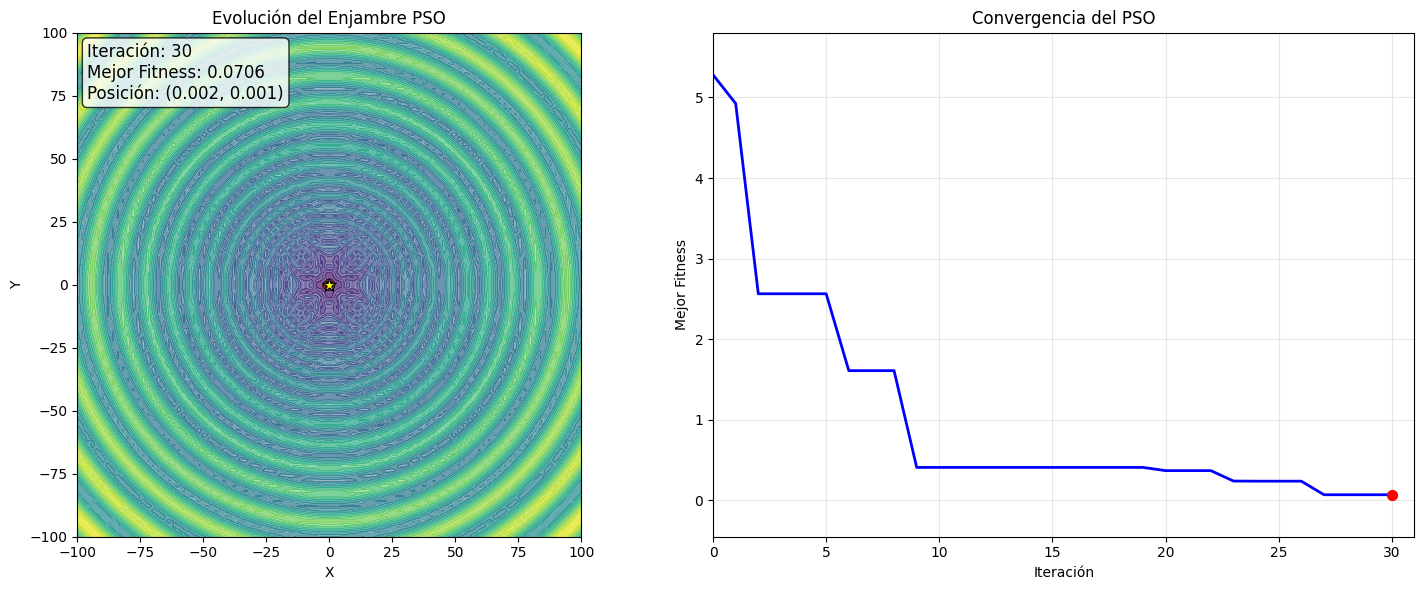

In [16]:
_ = pso_animated(fitness_function_f2, [-100, -100], [100, 100], n_particles=20, max_iter=30, 
            c1=0.5, c2=0.7, w=0.7, save_gif=True)